# 01 - Data Audit

This is the first narrative notebook. Before any factor work, we audit the data
layer the rest of the project sits on: the reconstructed S&P 500 membership
table and the per-ticker adjusted price history.

The heavy lifting lives in `qer.diagnostics.audit_data` (so it is unit-tested);
here we just call each function and read the result with surrounding commentary.

**Prerequisite:** the data must already be built. From the repo root:

```bash
make data        # build membership + ingest prices (+ sectors)
```

Each chart is paired with a short "what good looks like" note so a reviewer can
tell at a glance whether the data passed or failed the eyeball test.

In [ ]:
from qer.data.loader import DataLoader
from qer.diagnostics.audit_data import (
    plot_universe_size,
    plot_missingness_heatmap,
    plot_return_distribution_by_year,
    plot_sector_breakdown,
    check_no_future_leakage,
    check_historical_churn,
    check_spy_total_return,
    check_price_adjustment, 
)

In [2]:
loader = DataLoader()

## Membership table

The point-in-time membership table is the spine of the universe. Each row is one
contiguous interval a ticker spent in the index, entity-resolved so that renames
(FB -> META, PCLN -> BKNG) roll up under the current symbol.

- `start_date = NaT` means the addition predates Wikipedia's changes log.
- `end_date` at the 2099-12-31 sentinel means "still in the index today".

In [3]:
loader.membership.head()

,ticker,start_date,end_date
0,A,2000-06-05 00:00:00.000000000,2099-12-31
1,AA,1677-09-21 00:12:43.145224193,2016-11-01
2,AAL,2015-03-23 00:00:00.000000000,2024-09-23
3,AAP,2015-07-08 00:00:00.000000000,2023-08-25
4,AAPL,1982-11-30 00:00:00.000000000,2099-12-31


## Universe size over time

The active universe should hover near 500 with only mild drift. Brief excursions
above 500 are expected around same-day swaps and from dual-class tickers
(e.g. GOOG/GOOGL). A systematically *low* count before ~2011 is a known
limitation: Wikipedia's changes log thins out the further back you go.

<Axes: title={'center': 'Active universe size, 2008-01 to 2025-11'}, ylabel='Active tickers'>

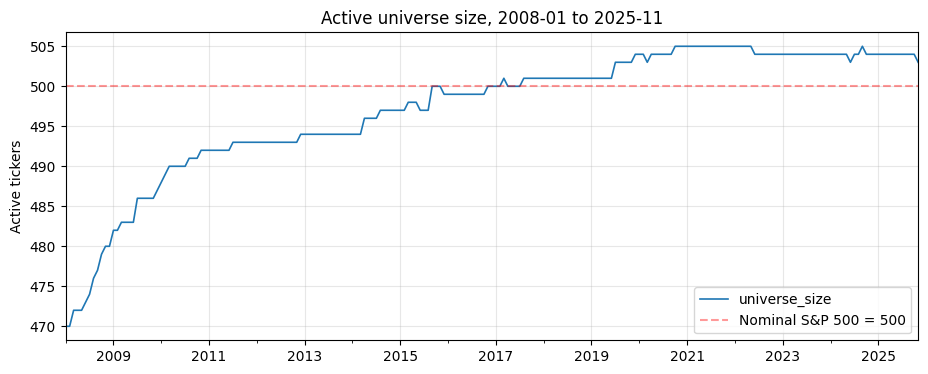

In [4]:
plot_universe_size(loader)

## Missing-data heatmap

Fraction of universe-active tickers with no price on each date, bucketed by
ticker name to stay readable. Bright cells flag dates where membership says a
name should be tradeable but we have no price - usually a delisted/acquired
ticker or a changes-log coverage gap before 2011. We want this mostly dark.

<Axes: title={'center': 'Missing-data heatmap: fraction of universe with NaN price'}>

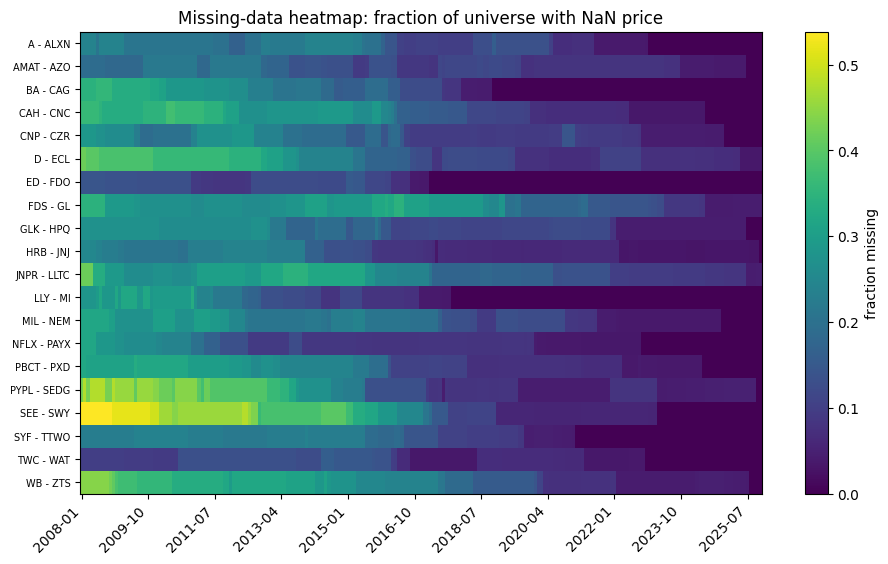

In [5]:
plot_missingness_heatmap(loader)

## Return distribution by year

A sanity check on the price data itself. The year-on-year shape should match
market memory: 2008 with fat tails, a calm 2017, a wide COVID-struck 2020, and
2022 wider than 2021. Anything wildly off (e.g. a year with near-zero dispersion)
points at an adjustment or ingestion bug rather than a real market regime.

<Axes: title={'center': 'Daily log-return distribution by year (whiskers = 1st/99th %ile)'}, ylabel='Log return'>

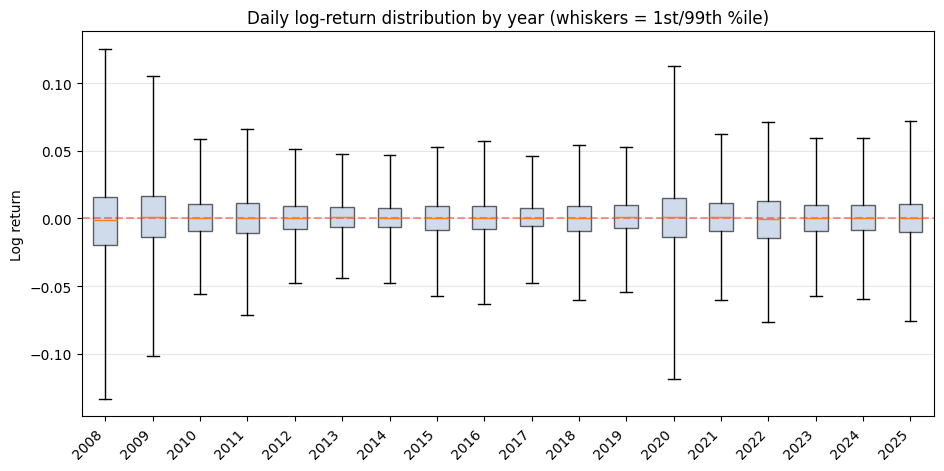

In [6]:
plot_return_distribution_by_year(loader)

## Sector breakdown

Universe composition by GICS sector at the latest date. This needs
`data/raw/sectors.parquet`; if it is missing the function prints a hint and
returns `None` rather than erroring, so the cell is safe to run either way.

```bash
make sectors     # or: python -m scripts.fetch_sectors
```

<Axes: title={'center': 'Universe by sector as of 2025-12-30 (503 tickers)'}, xlabel='Number of tickers', ylabel='sector'>

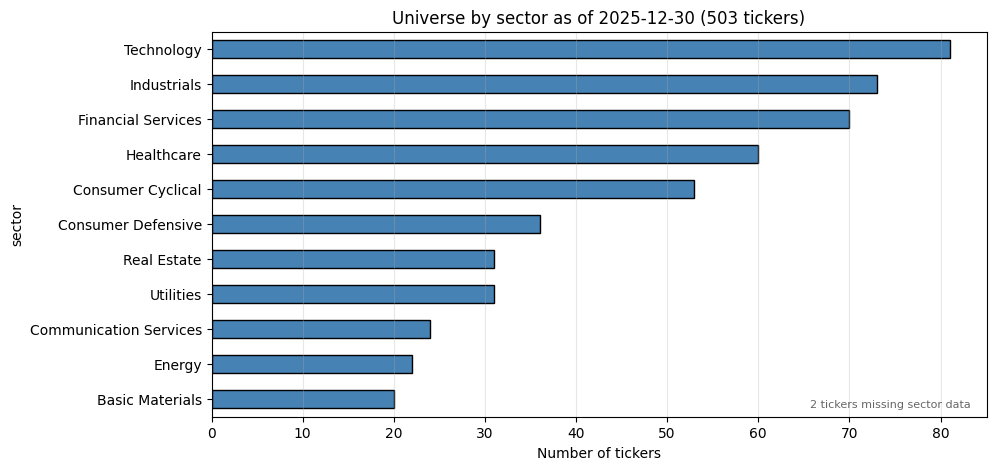

In [13]:
plot_sector_breakdown(loader)

## Sanity checks

Three asserts that fail loudly if the data layer is wrong. These are the
canaries; if any trips, stop and fix the data before trusting downstream
factors.

1. **No future leakage** - the queried universe on a date equals exactly the set
   of intervals covering that date; no future joiner sneaks in.
2. **Historical churn** - enough historical tickers have exited that we are not
   silently looking at a survivorship-biased, today's-constituents universe.
3. **SPY total return** - if SPY was ingested, its realised annualised return
   sits in a plausible band (self-skips if SPY is absent).
4. **Price adjustment** - every ticker's `adj close` is genuinely split/dividend
adjusted: no name has a cluster of >40% single-day moves (uncorrected splits),
and the universe is not silently identical to the raw close (adjustment never ran).

In [14]:
check_no_future_leakage(loader)

PASS: no future leakage at 2018-06-15 (universe size 501)


In [15]:
check_historical_churn(loader)

PASS: historical churn = 40.5% (343 of 846 tickers no longer in index)


In [16]:
check_spy_total_return()

SPY total return: +374.0% (+9.03% annualized) over 18.0 years (2008-01-02 to 2025-12-30)
PASS: SPY return within plausible band (tolerance=1%)


In [ ]:
check_price_adjustment(loader)

## Takeaways

If the universe hovers near 500, the heatmap is mostly dark, the yearly return
shapes match market memory, and all three checks pass, the data layer is sound
and we can move on to factors in `02_first_factor_momentum.ipynb`.